# Technical Assessment 2, Part 1: K-Nearest Neighbors


## Name: Dawn Andrei Pamesa
## Section: TS31


In [29]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

Loading the Dataset

In [30]:
df = pd.read_csv('diabetes.csv')
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [31]:
print("Shape:", df.shape)
df.info()

Shape: (768, 9)
<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [32]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [33]:
counts = df['Outcome'].value_counts().sort_index()
print("Non-Diabetic (0): {} ({:.1f}%)".format(counts[0], counts[0] / len(df) * 100))
print("Diabetic     (1): {} ({:.1f}%)".format(counts[1], counts[1] / len(df) * 100))

Non-Diabetic (0): 500 (65.1%)
Diabetic     (1): 268 (34.9%)


EDA

In [34]:
# Duplicate rows would let the same record influence the model twice.
print("Duplicate Rows:", df.duplicated().sum())
df = df.drop_duplicates()
print("Rows after Removing Duplicates:", len(df))

Duplicate Rows: 0
Rows after Removing Duplicates: 768


In [35]:
print("Missing Values Reported by Pandas:", df.isnull().sum().sum())

Missing Values Reported by Pandas: 0


In [36]:
# Five columns contain zeros that are physically impossible for a living patient.
# These are missing measurements recorded as 0, not real values.
zero_cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
pd.DataFrame({
    'zero_count': [(df[col] == 0).sum() for col in zero_cols],
    'percent': [round((df[col] == 0).mean() * 100, 1) for col in zero_cols],
}, index=zero_cols)

,zero_count,percent
Glucose,5,0.7
BloodPressure,35,4.6
SkinThickness,227,29.6
Insulin,374,48.7
BMI,11,1.4


In [37]:
# Correlation with the target BEFORE the impossible zeros are dealt with
corr_before = df.corr(numeric_only=True)['Outcome'].drop('Outcome').sort_values(ascending=False)
print(corr_before.round(3))

Glucose                     0.467
BMI                         0.293
Age                         0.238
Pregnancies                 0.222
DiabetesPedigreeFunction    0.174
Insulin                     0.131
SkinThickness               0.075
BloodPressure               0.065
Name: Outcome, dtype: float64


In [38]:
# Replace the impossible zeros with NaN so they are treated as missing.
df[zero_cols] = df[zero_cols].replace(0, np.nan)
print("Missing Values after the Correction:")
print(df.isnull().sum()[df.isnull().sum() > 0])

Missing Values after the Correction:
Glucose            5
BloodPressure     35
SkinThickness    227
Insulin          374
BMI               11
dtype: int64


In [39]:
# Correlation with the target AFTER the correction. Pandas ignores NaN here.
corr_after = df.corr(numeric_only=True)['Outcome'].drop('Outcome').sort_values(ascending=False)

comparison = pd.DataFrame({'before': corr_before, 'after': corr_after})
comparison['change'] = (comparison['after'] - comparison['before']).round(3)
comparison.round(3).sort_values('after', ascending=False)

,before,after,change
Glucose,0.467,0.495,0.028
BMI,0.293,0.314,0.021
Insulin,0.131,0.303,0.173
SkinThickness,0.075,0.259,0.185
Age,0.238,0.238,0.000
Pregnancies,0.222,0.222,0.000
DiabetesPedigreeFunction,0.174,0.174,0.000
BloodPressure,0.065,0.171,0.106


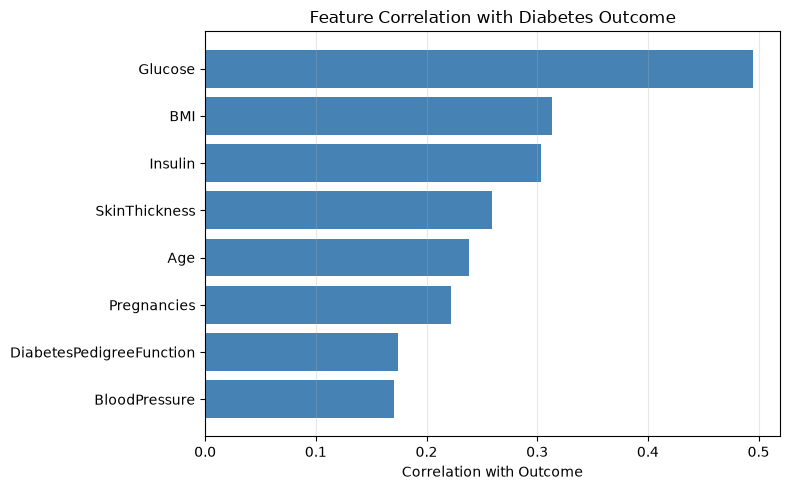

In [40]:
plt.figure(figsize=(8, 5))
plt.barh(corr_after.index[::-1], corr_after.values[::-1], color='steelblue')
plt.xlabel('Correlation with Outcome')
plt.title('Feature Correlation with Diabetes Outcome')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

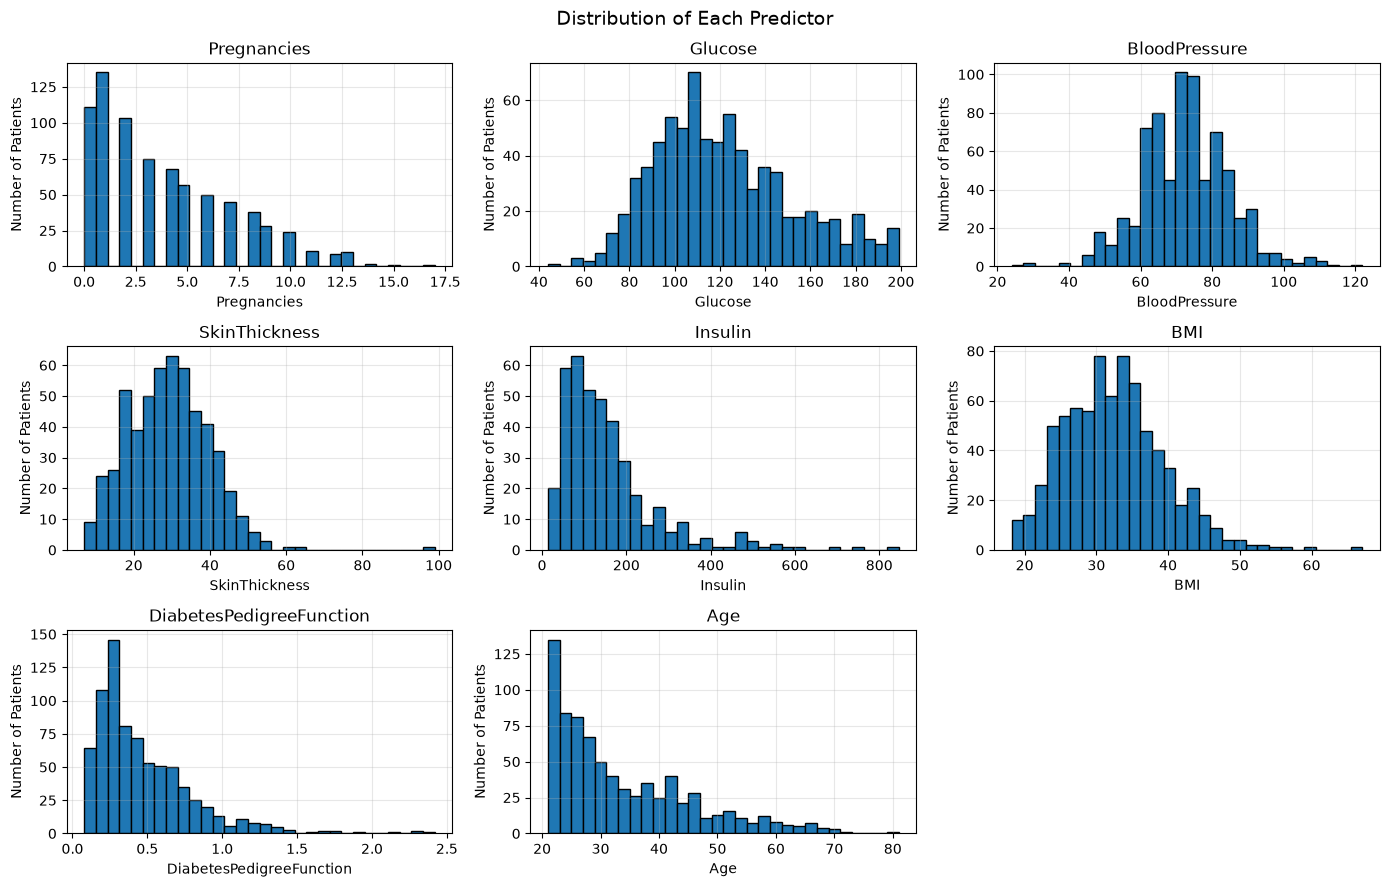

In [41]:
features = df.drop(columns='Outcome').columns
fig, axes = plt.subplots(3, 3, figsize=(14, 9))

for ax, column in zip(axes.flat, features):
    ax.hist(df[column].dropna(), bins=30, edgecolor='black')
    ax.set_title(column)
    ax.set_xlabel(column)
    ax.set_ylabel('Number of Patients')
    ax.grid(alpha=0.3)

axes.flat[-1].axis('off')

plt.suptitle('Distribution of Each Predictor', fontsize=14)
plt.tight_layout()
plt.show()

Setup: Split the Data, 75 / 25

In [42]:
X = df.drop(columns='Outcome')  
y = df['Outcome']

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

print("Training set:", X_train.shape, " Test set:", X_test.shape)

Training set: (576, 8)  Test set: (192, 8)


## 1. EDA - Feature Scaling

In [43]:
# Fill the missing values with the column mean 
imputer = SimpleImputer(strategy='mean')
X_train = pd.DataFrame(imputer.fit_transform(X_train), columns=X.columns)
X_test = pd.DataFrame(imputer.transform(X_test), columns=X.columns)

print("Missing Values Left in Training Set:", X_train.isnull().sum().sum())
print("Missing Values Left in Test Set:", X_test.isnull().sum().sum())

Missing Values Left in Training Set: 0
Missing Values Left in Test Set: 0


In [44]:
# KNN measures distance, so features on larger scales would dominate.
# StandardScaler puts every feature on mean 0, standard deviation 1.
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X.columns)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X.columns)

print("Before Scaling:")
print(X_train.describe().loc[['mean', 'std']].round(2))
print()
print("After Scaling:")
print(X_train_scaled.describe().loc[['mean', 'std']].round(2))

Before Scaling:
      Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin    BMI  \
mean         3.74   121.72          72.27          28.65   154.30  32.32   
std          3.31    30.08          12.10           8.39    86.93   6.88   

      DiabetesPedigreeFunction    Age  
mean                      0.47  32.92  
std                       0.34  11.51  

After Scaling:
      Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin  BMI  \
mean         -0.0     -0.0           -0.0            0.0      0.0  0.0   
std           1.0      1.0            1.0            1.0      1.0  1.0   

      DiabetesPedigreeFunction  Age  
mean                       0.0 -0.0  
std                        1.0  1.0  


## 2. Choose a Value for k and Prove Using a Plot

In [45]:
neighbors_settings = range(1, 31)
training_accuracy = []
test_accuracy = []

for n_neighbors in neighbors_settings:
    knn = KNeighborsClassifier(n_neighbors=n_neighbors)  
    knn.fit(X_train_scaled, y_train)                      
    training_accuracy.append(knn.score(X_train_scaled, y_train))
    test_accuracy.append(knn.score(X_test_scaled, y_test))

best_k = list(neighbors_settings)[int(np.argmax(test_accuracy))]
print("Optimal k = {}  (test accuracy {:.4f})".format(best_k, max(test_accuracy)))

Optimal k = 22  (test accuracy 0.7448)


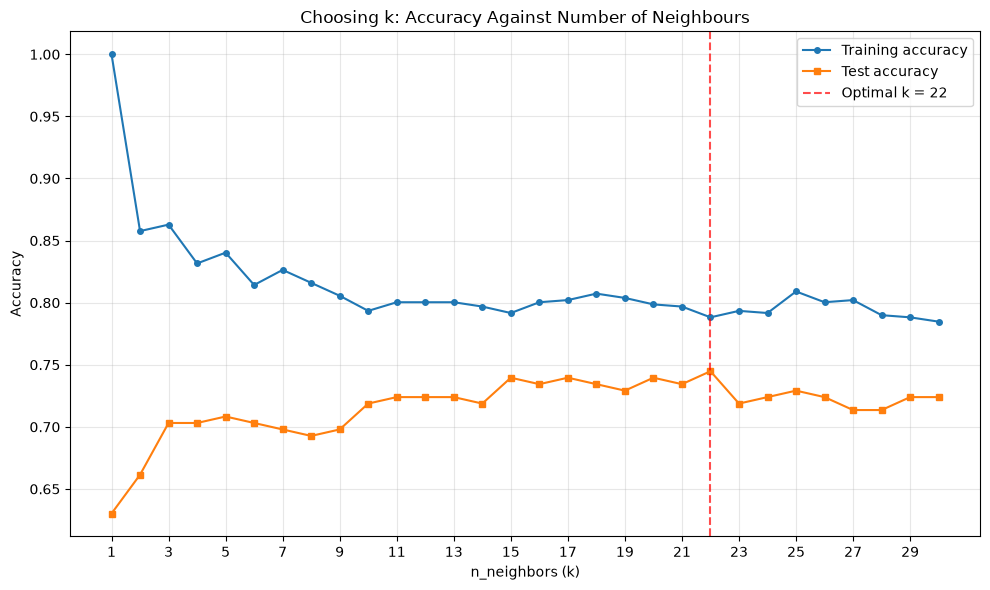

In [46]:
plt.figure(figsize=(10, 6))
plt.plot(neighbors_settings, training_accuracy, label='Training accuracy', marker='o', markersize=4)
plt.plot(neighbors_settings, test_accuracy, label='Test accuracy', marker='s', markersize=4)
plt.axvline(best_k, color='red', linestyle='--', alpha=0.7, label='Optimal k = {}'.format(best_k))
plt.xlabel('n_neighbors (k)')
plt.ylabel('Accuracy')
plt.title('Choosing k: Accuracy Against Number of Neighbours')
plt.xticks(list(neighbors_settings)[::2])
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 3. Train the Model

In [47]:
knn = KNeighborsClassifier(n_neighbors=best_k)
knn.fit(X_train_scaled, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",22
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance<https://docs.scipy.org/doc/scipy/reference/spatial.distance.html>`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.Doesn't affect :meth:`fit` method.",None
Name,Type,Value
"classes_ classes_: array of shape (n_classes,)Class labels known to the classifier","ndarray[int64](2,)","[0,1]"
"effective_metric_ effective_metric_: str or callbleThe distance metric used. It will be same as the `metric` parameteror a synonym of it, e.g. 'euclidean' if the `metric` parameter set to'minkowski' and `p` parameter set to 2.",str,'eu...an'


## 4. Predict Using the Test Data

In [48]:
y_pred = knn.predict(X_test_scaled)

print("Predicted for the First 30 Test Records:")
print(y_pred[:30])
print()
print("Actual for the Same Records:")
print(y_test.values[:30])

Predicted for the First 30 Test Records:
[0 0 0 0 0 1 0 0 0 0 0 1 0 0 0 0 0 0 1 0 0 0 0 0 1 1 0 0 0 0]

Actual for the Same Records:
[0 0 0 0 0 0 0 0 0 0 1 0 1 0 0 1 0 0 1 1 0 0 0 0 0 1 0 0 1 0]


## 5. Show the Accuracy of the Prediction

In [49]:
train_acc = knn.score(X_train_scaled, y_train)
test_acc = accuracy_score(y_test, y_pred)

print("Training Accuracy: {:.4f}  ({:.2f}%)".format(train_acc, train_acc * 100))
print("Test Accuracy: {:.4f}  ({:.2f}%)".format(test_acc, test_acc * 100))

Training Accuracy: 0.7882  (78.82%)
Test Accuracy: 0.7448  (74.48%)


In [50]:
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

print("Confusion Matrix:")
print(cm)
print()
print("Correctly Identified as Diabetic:", tp)
print("Diabetic Patients Missed:", fn)
print("Recall (Share of Diabetics Found): {:.3f}".format(tp / (tp + fn)))

Confusion Matrix:
[[107  16]
 [ 33  36]]

Correctly Identified as Diabetic: 36
Diabetic Patients Missed: 33
Recall (Share of Diabetics Found): 0.522


## 6. Predict Using a New Data (3 data)

In [51]:
new_data = pd.DataFrame([
    [1,  95, 70, 25,  80, 24.5, 0.200, 25],   
    [9, 180, 88, 40, 200, 38.5, 0.900, 52],   
    [3, 130, 74, 28, 110, 30.2, 0.450, 38],   
], columns=X.columns)

new_data

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,1,95,70,25,80,24.5,0.20,25
1,9,180,88,40,200,38.5,0.90,52
2,3,130,74,28,110,30.2,0.45,38


In [52]:
new_data_scaled = pd.DataFrame(
    scaler.transform(imputer.transform(new_data)), columns=X.columns)
new_prediction = knn.predict(new_data_scaled)

target_names = ['Non-diabetic', 'Diabetic']
for i, pred in enumerate(new_prediction):
    print("Patient {}: Prediction = {}  ->  {}".format(i + 1, pred, target_names[pred]))

Patient 1: Prediction = 0  ->  Non-diabetic
Patient 2: Prediction = 1  ->  Diabetic
Patient 3: Prediction = 1  ->  Diabetic


d:\School-Works\Machine Learning Algorithm\.venv\Lib\site-packages\sklearn\utils\validation.py:2830: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


## 7. Provide Visualization

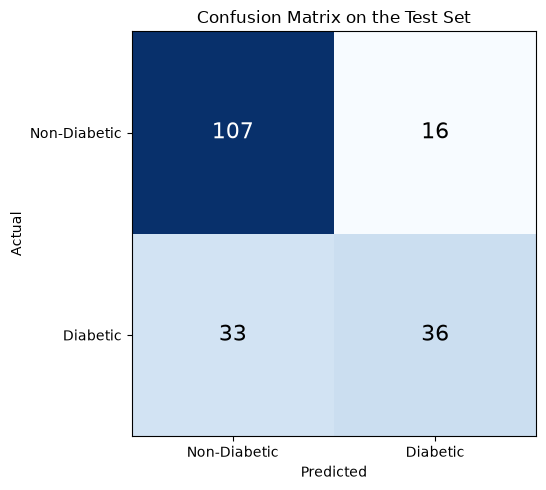

In [53]:
plt.figure(figsize=(6, 5))
plt.imshow(cm, cmap='Blues')
plt.title('Confusion Matrix on the Test Set')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.xticks([0, 1], ['Non-Diabetic', 'Diabetic'])
plt.yticks([0, 1], ['Non-Diabetic', 'Diabetic'])
for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha='center', va='center', fontsize=16,
                 color='white' if cm[i, j] > cm.max() / 2 else 'black')
plt.tight_layout()
plt.show()

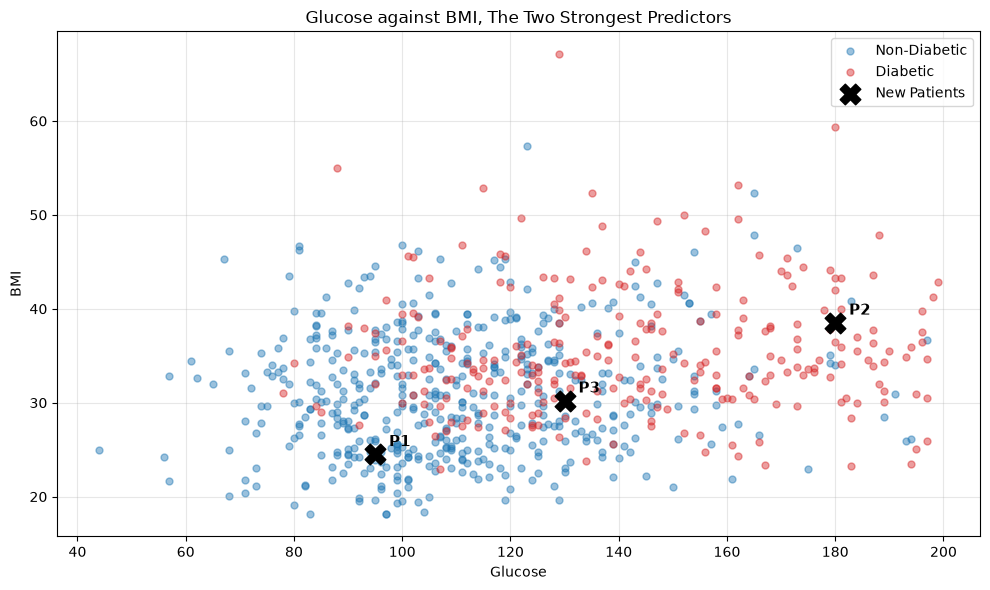

In [54]:
plt.figure(figsize=(10, 6))
for label, colour, name in [(0, 'tab:blue', 'Non-Diabetic'), (1, 'tab:red', 'Diabetic')]:
    subset = df[df['Outcome'] == label]
    plt.scatter(subset['Glucose'], subset['BMI'], c=colour, label=name, alpha=0.45, s=25)

plt.scatter(new_data['Glucose'], new_data['BMI'], c='black', marker='X', s=220,
            label='New Patients', zorder=5)
for i, row in new_data.iterrows():
    plt.annotate('P{}'.format(i + 1), (row['Glucose'], row['BMI']),
                 textcoords='offset points', xytext=(10, 6), fontsize=11, weight='bold')

plt.xlabel('Glucose')
plt.ylabel('BMI')
plt.title('Glucose against BMI, The Two Strongest Predictors')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 8. Provide Insight

**The dataset hides its missing values as zeros, and correcting that changes the analysis.**
Insulin is zero for 48.7 percent of the records and SkinThickness for 29.6 percent, which is
impossible for a living patient. Before the correction those two features looked almost useless,
correlating with the outcome at 0.131 and 0.075. Once the zeros are treated as missing and filled
with the column mean, the same features correlate at 0.303 and 0.259, and BloodPressure rises from
0.065 to 0.171. The zeros were not weak signal, they were absent measurements dragging the averages
towards a value no patient can have.

**Glucose is the strongest predictor either way.** It leads at 0.495 after the correction, ahead of
BMI at 0.314 and Insulin at 0.303. The scatter plot shows the same thing: the diabetic cases sit
towards the right of the glucose axis, and the two groups separate more clearly along glucose than
along BMI. All eight predictors were kept, so the weaker ones still contribute to the distance
calculation.

**Scaling is required, not optional.** KNN classifies a point by measuring straight-line distance
to its neighbours. Untouched, Insulin runs into the hundreds while DiabetesPedigreeFunction stays
below 2.5, so Insulin alone would decide almost every distance and the other seven features would
barely count. Standardising puts each predictor on the same footing.

**The shape of the k curve is the familiar one.** At k = 1 the training accuracy is far above the
test accuracy, which is overfitting: the prediction depends on a single nearest point. As k grows
the two curves move together and the test accuracy climbs. The optimum lands well into double
figures, which says the two classes overlap heavily and the model has to average over many
neighbours before its predictions settle.

**Accuracy alone flatters the model.** Roughly 64 percent of the test set is non-diabetic, so a
model that answered "non-diabetic" every single time would already look about 64 percent accurate.
The trained model does better than that, but the gap is smaller than the headline number suggests.

**The remaining weakness is the diabetics it misses.** The confusion matrix shows the model still
fails to identify a meaningful share of the patients who actually have diabetes. For screening,
that is the expensive error: a false negative sends an ill patient home, while a false positive
only triggers a second test. Handling the missing values improved this considerably, but it would
need further work, such as moving the decision threshold away from the default, before it was fit
for any real use.